# Домашнее задание: Generative Adversarial Networks

В этом домашнем задании вы потренируетесь применять GAN для генерации двумерных изображений из необычного распределения. Увидите достоинства и недостатки архитектуры.

In [3]:
%pip install torch
%pip install matplotlib
%pip install torchvision
%pip install -U scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 8.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 9.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from IPython.display import clear_output
from sklearn import datasets
from torch import nn, optim
from torchvision.datasets import MNIST
from typing_extensions import Literal

%matplotlib inline
device = "cuda:0" if torch.cuda.is_available() else "cpu"

Архитектуру GAN возьмем из [урока](https://colab.research.google.com/drive/1HzY0baVwowHVYzz5Xt_WVERl2Rlej5MB?usp=sharing).

In [ ]:
def train_gan(
    tr_dataloader,
    gen,
    discr,
    gen_opt,
    discr_opt,
    loss_func,
    prior,
    num_epochs,
    gen_steps,
    discr_steps,
    verbose_num_iters=100,
    storage=None
):
    gen.train()
    discr.train()
    gen_loss_trace = []
    discr_loss_trace = []

    iter_i = 0

    for epoch_i in range(num_epochs):
        print(f"Epoch {epoch_i + 1}")
        for batch in tr_dataloader:
            # берем реальные объекты
            real_objects, _ = batch
            real_objects = real_objects.to(device)

            # генерируем новые объекты
            num_objects = real_objects.shape[0]
            z = prior.sample((num_objects,))
            gen_objects = gen(z)

            # считаем скоры
            real_objects_scores, gen_objects_scores = torch.split(
                discr(torch.cat([real_objects, gen_objects], dim=0)),
                num_objects,
            )

            if (iter_i % (gen_steps + discr_steps)) < gen_steps:
                # делаем шаг обучения генератора
                gen_opt.zero_grad()
                gen_loss = loss_func(
                    real_objects_scores, gen_objects_scores, "generator"
                )
                gen_loss.backward()
                gen_opt.step()
                gen_loss_trace.append((iter_i, gen_loss.item()))
            else:
                # делаем шаг обучения дискриминатора
                discr_opt.zero_grad()
                discr_loss = loss_func(
                    real_objects_scores, gen_objects_scores, "discriminator"
                )
                discr_loss.backward()
                discr_opt.step()
                discr_loss_trace.append((iter_i, discr_loss.item()))

            iter_i += 1

            # раз в verbose_num_iters визуализируем наши лоссы и семплы
            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)
                plt.figure(figsize=(10, 5))

                plt.subplot(1, 3, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Generator loss")
                plt.plot([p[0] for p in gen_loss_trace], [p[1] for p in gen_loss_trace])

                plt.subplot(1, 3, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Discriminator loss")
                plt.plot(
                    [p[0] for p in discr_loss_trace],
                    [p[1] for p in discr_loss_trace],
                    color="orange",
                )

                gen.eval()

                plt.subplot(1, 3, 3)
                with torch.no_grad():
                    z = prior.sample((1024,))
                    sampled_2d = gen(z)
                x = real_objects.cpu().numpy()
                plt.xlim(x.min(0)[0], x.max(0)[0])
                plt.ylim(x.min(0)[1], x.max(0)[1])
                plt.scatter(
                    sampled_2d[:, 0].cpu().detach().numpy(),
                    sampled_2d[:, 1].cpu().detach().numpy(),
                    s=1,
                )
                if storage is not None:
                  storage.append(sampled_2d.cpu().detach().numpy())

                plt.show()
                gen.train()

    gen.eval()
    discr.eval()

In [9]:
class Dataset2d:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

    def __len__(self):
        return self.x.shape[0]


class Generator2d(nn.Module):
    def __init__(self, lat_size):
        super().__init__()
        self.lat_size = lat_size

        self.net = nn.Sequential(
            nn.Linear(lat_size, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class Discriminator2d(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## Задание 1

При помощи функции `datasets.make_circles` сгенерируйте 10000 точек из заданного функцией распределения, с шумом `noise=0.01`.

Визуализируйте полученные объекты на плоскости.

Что вы видите?

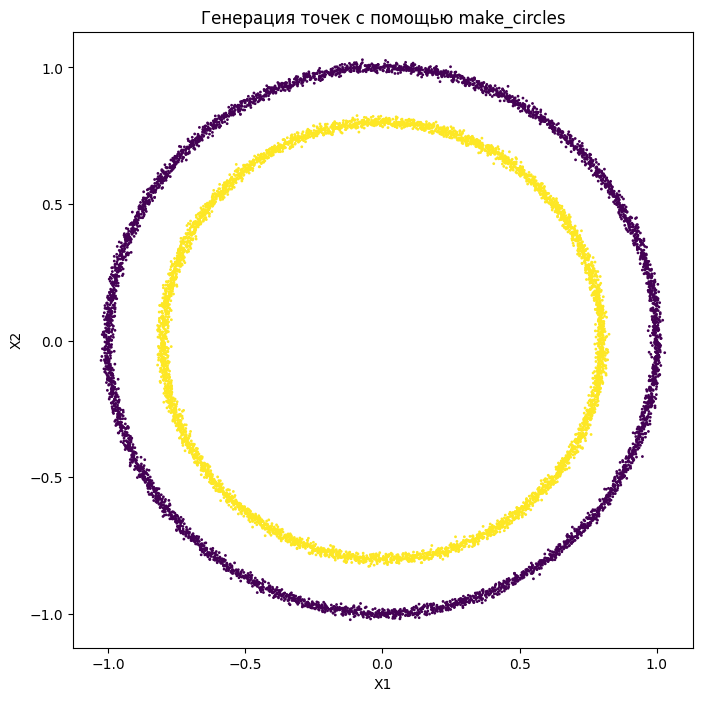

In [7]:
s_x, s_y = datasets.make_circles(n_samples=10000,noise=0.01)
# Визуализация
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=1)
plt.title('Генерация точек с помощью make_circles')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axis('equal')
plt.show()

## Задание 2

Воспользуйтесь [кодом из урока](https://colab.research.google.com/drive/1HzY0baVwowHVYzz5Xt_WVERl2Rlej5MB?usp=sharing) и по аналогии

* Задайте даталоадер

* Объявите генератор с параметром `lat_size=2` и дискриминатор

* Задайте prior - двумерное стандартное нормальное распределение

* Задайте оптимизаторы для генератора и дискриминатора: Adam с теми же гиперпараметрами, что и в коде с урока

Сколько параметров (весов) в сумме имеют генератор и дискриминатор?

In [10]:
tr_dataloader_2d = torch.utils.data.DataLoader(
    Dataset2d(torch.tensor(s_x, dtype=torch.float32), torch.tensor(s_y)),
    batch_size=64,
    shuffle=True,
    num_workers=64,
)

gen_2d = Generator2d(2)
gen_2d.to(device)

discr_2d = Discriminator2d()
discr_2d.to(device)

prior_2d = torch.distributions.Normal(
    torch.zeros(2).to(device), torch.ones(2).to(device)
)

gen_opt_2d = optim.Adam(gen_2d.parameters(), lr=3e-4)
discr_opt_2d = optim.Adam(discr_2d.parameters(), lr=3e-4, betas=(0.9, 0.999))

storage_2d = []

/home/roman/Documents/hse-finish/hse-24-25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 64 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [11]:
total_params = sum(p.numel() for p in gen_2d.parameters())
print(f"Общее количество весов: {total_params}")

total_params = sum(p.numel() for p in discr_2d.parameters())
print(f"Общее количество весов: {total_params}")

Общее количество весов: 2466
Общее количество весов: 2241


## Задание 3

Запустите обучение GAN с теми же гиперпараметрами, что и в уроке.

После обучения сгенерируйте 1024 случайных объекта из нормального распределения и к ним примените генератор обученного GAN. Визуализируйте результат.

Что у вас получилось?

In [ ]:
# ваш код здесь

## Задание 4

С какой проблемой GAN вы столкнулись в этом задании?

## Задание 5

Увеличьте число нейронов на скрытых слоях сети с 32 до 64 (во всех шагах, где 32 нейрона). Заново запустите обучение.

Удалось ли справиться с проблемой, которую мы наблюдали выше?